# Week 5: Dynamic Hedging Simulation

This notebook extends the single-path delta hedging table from [Week 4](../week4_greeks/greeks.ipynb) 
to 1000 independent GBM paths. Where Week 4 asked *"does the hedge work?"*, 
Week 5 asks *"what does the distribution of hedging outcomes look like across many paths?"*

## Setup

Same parameters as Week 4's hedging table — same stock, same option, same 20-week horizon.

In [81]:
from scipy.stats import norm
from math import log, sqrt, exp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Setup inputs
s_0 = 49
k = 50
r = 0.05
mu = 0.15
sigma = 0.30
T = 20/52        # 20 weeks in years
N = 20     # one step per week
dt = T / N # = 1/52
num_paths = 1000
n_options = 100000

# Generating random draws
Z = np.random.standard_normal((num_paths, N))

## Generating 1000 GBM Paths

Recall from Week 1 that GBM evolves the stock price as:

$$S_{t+1} = S_t \cdot \exp\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} \cdot Z\right)$$

Each simulation produces $N+1$ price points — weekly snapshots from $S_0$ through $S_{20}$. 
We generate 1000 independent paths, each a possible future for the stock.

In [82]:
#  Building price paths in GBM
prices = np.zeros ((num_paths, N+1))
prices[:, 0] = s_0         
for t in range(1, N+1):
            prices[:, t] = prices[:, t-1] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

# Show a sample of values from GBM walk
np.set_printoptions(precision=2, suppress=True)
print(prices[:3])

[[49.   49.35 49.69 45.41 45.64 46.99 46.65 47.5  44.62 44.2  43.63 42.33
  39.91 42.36 44.44 44.91 45.09 46.97 47.85 52.25 53.94]
 [49.   48.19 47.17 46.77 47.01 42.93 40.72 39.83 41.96 39.94 39.13 40.63
  43.49 42.02 40.81 43.15 46.21 44.27 46.37 45.03 43.87]
 [49.   48.39 44.94 44.62 42.52 45.45 46.38 47.55 48.54 53.2  51.96 52.2
  51.56 51.44 48.64 47.29 47.27 46.96 46.91 46.47 47.14]]


## BSM Functions

We reuse the BSM pricer and delta function from Week 3 and Week 4. 
At each hedging step, BSM is called with the *current stock price* and *time remaining* 
to get the current delta — how many shares we should be holding right now.

In [83]:

# Function for d1 and d2
def d_1(sigma, s_0, k, r, T):
    d_1 = (log(s_0/k)+(r+(sigma**2)/2)*T)/((sigma)*sqrt(T))
    return d_1

def d_2(sigma, s_0, k, r, T): 
    return d_1(sigma, s_0, k, r, T) - (sigma)*sqrt(T)

# Identifying option prices using BSM
def compute_delta_hedge(sigma, S, k, r, T_remaining):
    if T_remaining <= 0:
        return 1.0 if S > k else 0.0
    return norm.cdf(d_1(sigma, S, k, r, T_remaining))

# BSM call pricer only
def bsm(sigma, s_0, k, r, T):
    d1 = d_1(sigma, s_0, k, r, T)
    d2 = d_2(sigma, s_0, k, r, T)
    opt_price = s_0 * norm.cdf(d1) - k * exp(-r * T) * norm.cdf(d2)
    return opt_price

# Compute options cost with BSM:
bsm_price = bsm(sigma, s_0, k, r, T) * n_options



## The Hedge Account

Rather than tracking gross share purchases and sales separately, we model a single 
**hedge account** — think of it as the cash account funding the hedging operation.

It works like this:

| Event | Effect on account |
|-------|-------------------|
| t = 0 | Seeded with BSM premium collected from selling the option |
| Each week | Grown by one period of interest $e^{r \Delta t}$, then debited/credited for share rebalancing |
| Expiry | Credited for liquidating remaining share position, debited for option payoff if ITM |

The P&L for each path is simply whatever remains in the account at expiry:

$$\text{P\&L} = \text{hedge account at } T$$

If BSM were perfect and hedging were continuous, this would be exactly zero on every path. 
Discrete weekly rehedging introduces residual error — the distribution of that error 
across 1000 paths is what we are studying.

In [84]:
# Build pnl list
pnl_list = []

for i in range(num_paths):
    stock_prices = prices[i]
    
    hedge_account = bsm_price  # start with premium collected
    shares_held = 0.0
    
    for t in range(N):
        # Grow account by one period of interest
        hedge_account *= exp(r * dt)
        
        # Compute new delta
        T_remaining = T - t * dt
        new_delta = compute_delta_hedge(sigma, stock_prices[t], k, r, T_remaining)
        
        # Rebalance: buy/sell shares
        shares_to_trade = new_delta * n_options - shares_held
        hedge_account -= shares_to_trade * stock_prices[t]
        shares_held = new_delta * n_options  # already in share units
    
    # Expiry: liquidate shares, pay option payoff
    hedge_account += shares_held * stock_prices[-1]
    option_payoff = max(stock_prices[-1] - k, 0) * n_options
    hedge_account -= option_payoff
    
    pnl_list.append(hedge_account)

## P&L Distribution Across 1000 Paths

With 1000 final P&L values collected, we plot the distribution. Two things to look for:

- **Mean ≈ 0** — the hedge is fair on average; BSM premium is the correct price
- **Spread/Standard Deviation** — the width of the distribution is the discrete hedging error; 
  residual risk from rebalancing only once per week

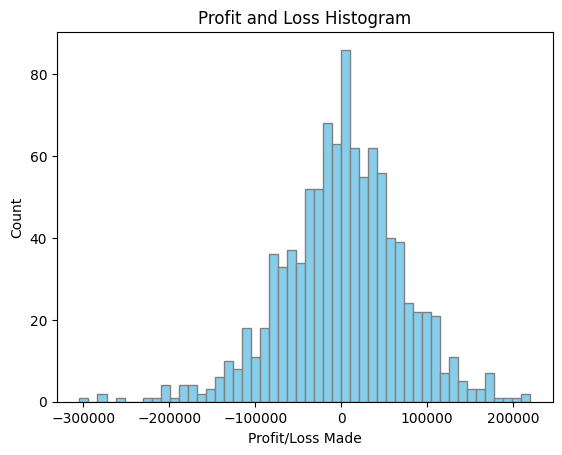

Mean is: 858.77
Discrete Hedging Error is: 70015.29


In [85]:
plt.hist(pnl_list, bins=50, color="skyblue", edgecolor="gray")

plt.xlabel("Profit/Loss Made")
plt.ylabel("Count")
plt.title("Profit and Loss Histogram")

plt.show()
print(f"Mean is: {np.mean(pnl_list):.2f}")
print(f"Discrete Hedging Error is: {np.std(pnl_list):.2f}")